# Imports:

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Loading Dataset:

In [173]:
credit_risk_dataset = pd.read_csv("../data/raw/credit_risk.csv", index_col=0)

# First look on data:

In [174]:
credit_risk_dataset.head(3)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [175]:
credit_risk_dataset.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [176]:
credit_risk_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [177]:
credit_risk_dataset.shape

(150000, 11)

## Initial Data Overview

**Shape:** 150,000 rows, 11 columns

**Numerical (int) columns (7):**
1. `delinquent_2yrs` — target variable
2. `age`
3. `late_30_59_count`
4. `open_credit_lines`
5. `late_90_count`
6. `real_estate_loans`
7. `late_60_89_count`

**Numerical (float) columns (4):**
1. `credit_utilization`
2. `debt_ratio`
3. `monthly_income`
4. `dependents`

**Missing values:**
- `monthly_income`: 29,731 missing (~19.8%)
- `dependents`: 3,924 missing (~2.6%)

**Duplicated rows:** 609

Several columns also show suspicious extreme values (`age` min = 0, `debt_ratio` and `credit_utilization` extreme maximums, sentinel-like values in the "late payment" columns). These are investigated in the Data Cleaning section below.



# Rename columns:

In [178]:
credit_risk_dataset.columns = ['delinquent_2yrs', 'credit_utilization', 'age', 'late_30_59_count', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90_count', 'real_estate_loans', 'late_60_89_count', 'dependents']
credit_risk_dataset.head(3)

,delinquent_2yrs,credit_utilization,age,late_30_59_count,debt_ratio,monthly_income,open_credit_lines,late_90_count,real_estate_loans,late_60_89_count,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [179]:
credit_risk_dataset.select_dtypes(include=["int64"]).columns

Index(['delinquent_2yrs', 'age', 'late_30_59_count', 'open_credit_lines',
       'late_90_count', 'real_estate_loans', 'late_60_89_count'],
      dtype='object')

In [180]:
credit_risk_dataset.select_dtypes(include=["float64"]).columns

Index(['credit_utilization', 'debt_ratio', 'monthly_income', 'dependents'], dtype='object')

In [181]:
credit_risk_dataset.isnull().sum()

delinquent_2yrs           0
credit_utilization        0
age                       0
late_30_59_count          0
debt_ratio                0
monthly_income        29731
open_credit_lines         0
late_90_count             0
real_estate_loans         0
late_60_89_count          0
dependents             3924
dtype: int64

## Data Cleaning

Before diving into individual feature anomalies, we start by removing exact duplicate rows, then investigate suspicious values found during the initial overview.

### Duplicate Rows

In [182]:
credit_risk_dataset.duplicated().sum()

np.int64(609)

In [183]:
credit_risk_dataset[credit_risk_dataset.duplicated()]

,delinquent_2yrs,credit_utilization,age,late_30_59_count,debt_ratio,monthly_income,open_credit_lines,late_90_count,real_estate_loans,late_60_89_count,dependents
1670,0,1.0,29,0,0.0,NaN,0,0,0,0,0.0
7824,0,1.0,29,0,0.0,NaN,0,0,0,0,0.0
7921,0,1.0,22,0,0.0,820.0,1,0,0,0,0.0
8841,0,1.0,23,0,0.0,820.0,1,0,0,0,0.0
10870,0,1.0,73,0,0.0,NaN,2,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149140,0,0.0,77,0,0.0,NaN,2,0,0,0,0.0
149432,0,1.0,25,0,0.0,NaN,1,0,0,0,NaN
149473,0,1.0,84,0,0.0,NaN,1,0,0,0,0.0
149770,0,1.0,23,98,0.0,NaN,0,98,0,98,NaN


In [184]:
credit_risk_dataset = credit_risk_dataset.drop_duplicates()

### Age Anomaly

The initial overview showed a minimum age of 0, which is not a valid value for someone holding a credit line. We check how many rows are affected before deciding how to handle them.

In [185]:
(credit_risk_dataset["age"] == 0).sum()

np.int64(1)

In [186]:
credit_risk_dataset = credit_risk_dataset[credit_risk_dataset["age"] != 0]

### Late Payment Columns — Sentinel Values

The three "late payment" columns (`late_30_59_count`, `late_60_89_count`, `late_90_count`) all share the same maximum value of 98, which is suspicious for a count variable. We check whether values of 96 and 98 appear consistently across all three columns for the same rows, which would suggest these are placeholder/error codes rather than genuine payment counts.

In [187]:
(credit_risk_dataset["late_30_59_count"].isin([96,98])).sum()

np.int64(225)

In [188]:
(credit_risk_dataset["late_90_count"].isin([96,98])).sum()

np.int64(225)

In [189]:
(credit_risk_dataset["late_60_89_count"].isin([96,98])).sum()

np.int64(225)

In [190]:
(credit_risk_dataset["late_30_59_count"].isin([96,98]) & (credit_risk_dataset["late_90_count"].isin([96,98])) & credit_risk_dataset["late_60_89_count"].isin([96,98])).sum()

np.int64(225)

In [191]:
credit_risk_dataset["has_late_data_anomaly"] = credit_risk_dataset["late_30_59_count"].isin([96,98]) & credit_risk_dataset["late_90_count"].isin([96,98]) & credit_risk_dataset["late_60_89_count"].isin([96,98])

### Debt Ratio — Extreme Values

`debt_ratio` shows an extremely skewed distribution (median ≈ 0.37, max ≈ 329,664). Rather than blindly applying an IQR-based cutoff, we first investigate *why* these extreme values occur, since `debt_ratio` is mathematically defined as debt divided by income — a near-zero or missing income can inflate this ratio artificially.

In [192]:
Q1 = credit_risk_dataset['debt_ratio'].quantile(0.25)
Q3 = credit_risk_dataset['debt_ratio'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}, upper_bound = {upper_bound}")

Q1 = 0.177441007, Q3 = 0.8752940652500001, IQR = 0.6978530582500001, upper_bound = 1.9220736526250002


In [193]:
credit_risk_dataset.loc[credit_risk_dataset.debt_ratio > upper_bound, 'monthly_income']

7         NaN
9         NaN
15        0.0
17        NaN
33        NaN
         ... 
149977    NaN
149978    NaN
149985    NaN
149993    NaN
149998    NaN
Name: monthly_income, Length: 31285, dtype: float64

### Missing Values

`monthly_income` and `dependents` contain missing values. For each, we first create a binary flag column marking where the original value was missing (preserving that information as a potential signal), then fill the gap using the median — chosen over the mean because both distributions are right-skewed and the median is more robust to extreme outliers.

In [194]:
credit_risk_dataset["monthly_income_nan"] = credit_risk_dataset["monthly_income"].isna()

In [195]:
credit_risk_dataset['monthly_income'] = credit_risk_dataset['monthly_income'].fillna(credit_risk_dataset['monthly_income'].median())

In [196]:
credit_risk_dataset['dependents_nan'] = credit_risk_dataset['dependents'].isna()

In [197]:
credit_risk_dataset['dependents'] = credit_risk_dataset['dependents'].fillna(credit_risk_dataset['dependents'].median())

## Data Cleaning Summary

- Removed 609 exact duplicate rows
- Removed 1 row with an invalid `age` of 0
- Identified and flagged 225 rows with sentinel values (96/98) across all three late-payment columns (`has_late_data_anomaly`)
- Filled missing `monthly_income` (~19.8%) and `dependents` (~2.6%) with the median, preserving missingness via `monthly_income_nan` / `dependents_nan` flags
- Left `debt_ratio` unmodified after confirming its extreme values are largely explained by missing/near-zero income rather than being an independent data issue

**Final shape:** 149,390 rows × 14 columns

In [198]:
credit_risk_dataset.shape

(149390, 14)

## Exploratory Data Analysis

### Target Distribution

In [199]:
credit_risk_dataset["delinquent_2yrs"].value_counts()

delinquent_2yrs
0    139381
1     10009
Name: count, dtype: int64

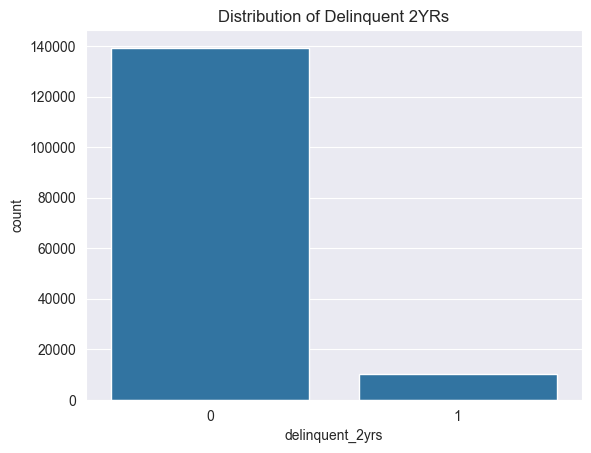

In [200]:
sns.countplot(x = credit_risk_dataset["delinquent_2yrs"])
plt.title("Distribution of Delinquent 2YRs")
plt.savefig("../images/distribution_delinquent_2yrs.png")
plt.show()

### Target Distribution — Finding

Roughly 6.7% of borrowers experienced serious delinquency, confirming a significant class imbalance that will need to be addressed at the modeling stage (e.g. via `class_weight` or resampling).

### Monthly Income vs Target

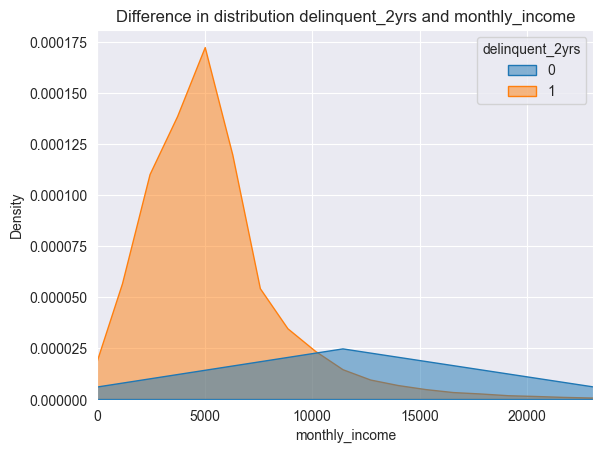

In [201]:
limit = credit_risk_dataset['monthly_income'].quantile(0.99)

sns.kdeplot(data=credit_risk_dataset, x='monthly_income', hue='delinquent_2yrs', fill=True, common_norm=False, alpha=0.5)

plt.xlim(0, limit)

plt.title('Difference in distribution delinquent_2yrs and monthly_income')
plt.savefig("../images/distribution_delinquent_2yrs_monthly_income.png")
plt.show()



The KDE plot shows a visible shift — the delinquent group is concentrated at lower income levels — but as the group medians later confirm, this difference is modest relative to how it first appears.

### Comparing Feature Means and Medians by Target

We compare mean and median values across the two target groups. Because several features (`debt_ratio`, `credit_utilization`) are heavily skewed with extreme outliers, the mean can be misleading — the median is checked as a more robust comparison.

In [202]:
credit_risk_dataset.groupby('delinquent_2yrs').mean()

,credit_utilization,age,late_30_59_count,debt_ratio,monthly_income,open_credit_lines,late_90_count,real_estate_loans,late_60_89_count,dependents,has_late_data_anomaly,monthly_income_nan,dependents_nan
delinquent_2yrs,,,,,,,,,,,,,
0,6.193063,52.763268,0.258091,358.662923,6485.435906,8.522941,0.112526,1.024695,0.104003,0.726562,0.000639,0.197782,0.026187
1,4.373001,45.947048,2.284844,295.620123,5593.707363,7.895594,1.987112,0.990209,1.723449,0.932860,0.013588,0.165251,0.017784


In [203]:
credit_risk_dataset.groupby('delinquent_2yrs').median()

,credit_utilization,age,late_30_59_count,debt_ratio,monthly_income,open_credit_lines,late_90_count,real_estate_loans,late_60_89_count,dependents,has_late_data_anomaly,monthly_income_nan,dependents_nan
delinquent_2yrs,,,,,,,,,,,,,
0,0.133383,52.0,0.0,0.364387,5400.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.837702,45.0,0.0,0.428946,5227.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**Key finding:** the mean comparison for `credit_utilization` (6.19 vs 4.37) is distorted by extreme outliers and even suggests the wrong direction. The median comparison (0.13 vs 0.84) reveals the true, much stronger relationship: people who use nearly all of their available credit limit are far more likely to become delinquent. The three late-payment count columns also show a very large gap between groups (up to 17x), making them likely strong predictors.

### Credit Utilization vs Target

Following the median finding above, we visualize the full distribution of `credit_utilization` by target group (clipped at the 99th percentile to keep the chart readable).

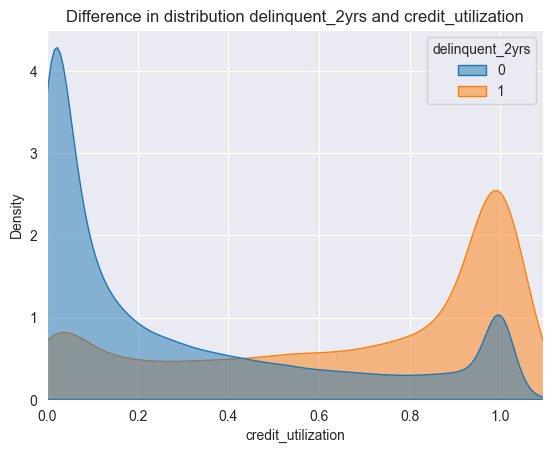

In [204]:
limit = credit_risk_dataset['credit_utilization'].quantile(0.99)

clipped = credit_risk_dataset[credit_risk_dataset['credit_utilization'] <= limit]
sns.kdeplot(data=clipped, x='credit_utilization', hue='delinquent_2yrs', fill=True, common_norm=False, alpha=0.5)

plt.xlim(0, limit)

plt.title('Difference in distribution delinquent_2yrs and credit_utilization')
plt.savefig("../images/distribution_delinquent_2yrs_credit_utilization.png")
plt.show()

This confirms the finding numerically: the delinquent group shows a clear peak near full credit utilization, while the non-delinquent group is concentrated near low utilization.

### Dependents and Debt Ratio vs Target

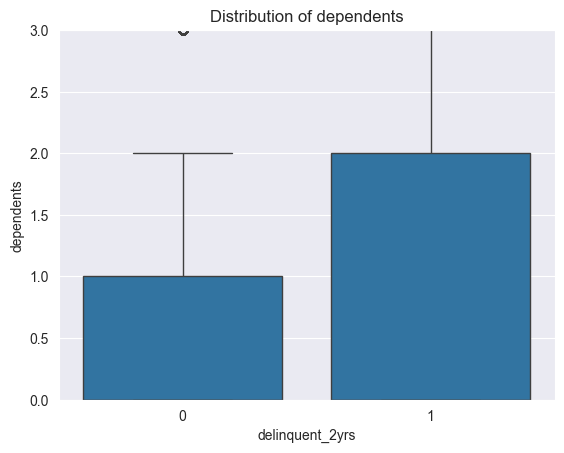

In [205]:
sns.boxplot(data=credit_risk_dataset, y="dependents", x="delinquent_2yrs")
plt.ylim(0, 3)
plt.title("Distribution of dependents")
plt.savefig("../images/distribution_dependents.png")
plt.show()

`dependents` shows a moderate association — the delinquent group's box is shifted slightly higher. `debt_ratio` required a log scale to be readable due to extreme outliers; once visible, it shows only a weak difference between groups.

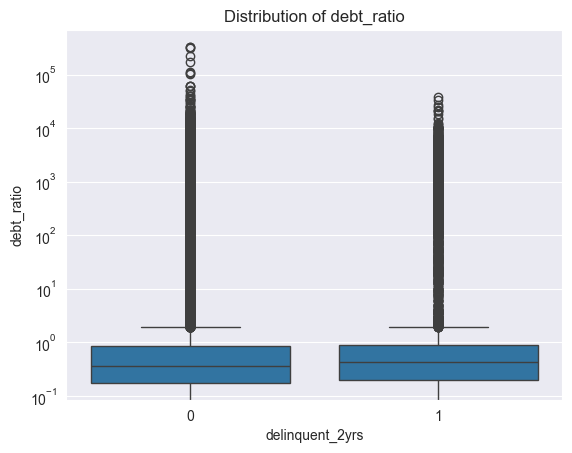

In [206]:
sns.boxplot(data=credit_risk_dataset, y="debt_ratio", x="delinquent_2yrs")
plt.yscale('log')
plt.title("Distribution of debt_ratio")
plt.savefig("../images/distribution_debt_ratio.png")
plt.show()

### Correlation Analysis

We start with the standard Pearson correlation matrix.

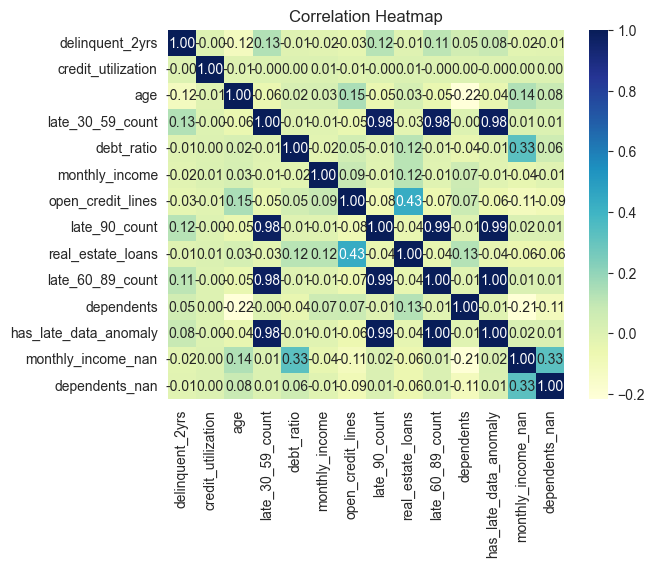

In [207]:
sns.heatmap(credit_risk_dataset.corr(), annot=True, cmap="YlGnBu", fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap_pearson.png")
plt.show()

Pearson correlation with the target is surprisingly weak across the board — most notably, `credit_utilization` shows almost 0.00 correlation despite the strong relationship seen above. This is because Pearson correlation is sensitive to extreme outliers and only captures linear relationships, both of which distort the result for this heavily skewed feature.

Since Pearson correlation is unreliable here, we recompute using Spearman correlation, which is rank-based and robust to outliers and non-linear relationships.

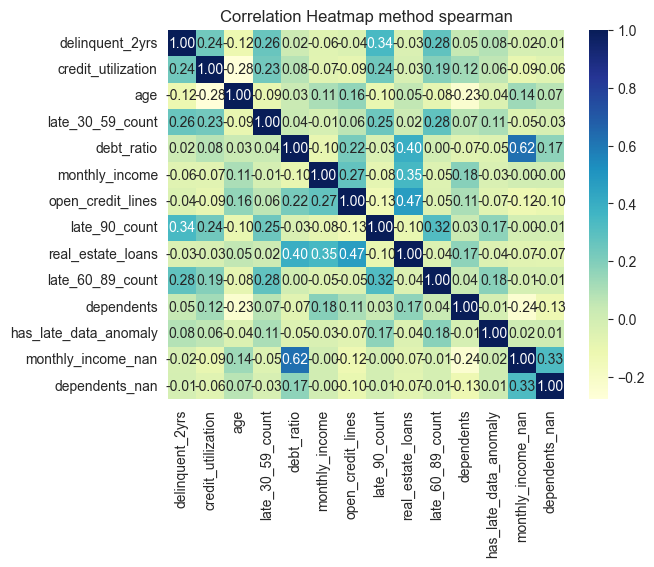

In [208]:
sns.heatmap(credit_risk_dataset.corr(method='spearman'), annot=True, cmap="YlGnBu", fmt='.2f')
plt.title("Correlation Heatmap method spearman")
plt.savefig("../images/correlation_heatmap_spearman.png")
plt.show()

## EDA Summary

Spearman correlation gives a far more trustworthy picture:

- **Strongest predictors of delinquency:** past late payments (`late_90_count`: 0.34, `late_60_89_count`: 0.28, `late_30_59_count`: 0.26) and `credit_utilization` (0.24)
- **Weak predictors:** `monthly_income` and `debt_ratio` show little direct correlation with the target, though `debt_ratio` is strongly linked to missing income (`monthly_income_nan`: 0.62), confirming the root cause identified during data cleaning
- **Class imbalance** (~6.7% positive) will need to be handled explicitly during modeling

These findings directly answer the project's research questions and set the direction for feature selection in the modeling phase.

In [209]:
credit_risk_dataset.to_csv("../data/processed/credit_risk_cleaned.csv", index=False)

 ## Preparing data for model:

We load the cleaned dataset and separate features (`X`) from the target (`y`). `has_late_data_anomaly` is excluded from `X` — it is a data quality flag describing a collection error, not a behavioral characteristic of the borrower, so including it as a predictor would not be meaningful.

In [210]:
credit_risk_cleaned = pd.read_csv("../data/processed/credit_risk_cleaned.csv")
X = credit_risk_cleaned.drop(columns=['has_late_data_anomaly', 'delinquent_2yrs'])
y = credit_risk_cleaned['delinquent_2yrs']

### Train-test split

The split uses `stratify=y` to preserve the ~6.7%/93.3% class balance in both the train and test sets. Features are also scaled with `StandardScaler`, since `monthly_income` and `credit_utilization` are on very different numeric ranges — this is required for Logistic Regression, which is sensitive to feature scale, but not for Random Forest, which is not.

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

### Baseline: Logistic Regression

Both models use `class_weight='balanced'` to counteract the class imbalance, since without it a model can achieve high accuracy simply by predicting the majority class. Two versions are compared — unscaled and scaled — since Logistic Regression failed to converge on unscaled features.

In [212]:
baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model_scaled = LogisticRegression(class_weight='balanced', random_state=42)

baseline_model.fit(X_train, y_train)

baseline_model_scaled.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_pred_baseline_scaled = baseline_model_scaled.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

print(confusion_matrix(y_test, y_pred_baseline_scaled))
print(classification_report(y_test, y_pred_baseline_scaled))


[[24606  3270]
 [  811  1191]]
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     27876
           1       0.27      0.59      0.37      2002

    accuracy                           0.86     29878
   macro avg       0.62      0.74      0.65     29878
weighted avg       0.92      0.86      0.89     29878

[[22464  5412]
 [  684  1318]]
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     27876
           1       0.20      0.66      0.30      2002

    accuracy                           0.80     29878
   macro avg       0.58      0.73      0.59     29878
weighted avg       0.92      0.80      0.84     29878



C:\Users\yanpa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scaling fixed the convergence warning, but changed the precision/recall trade-off: recall improved (0.59 → 0.66) at the cost of precision (0.27 → 0.20). Neither version is objectively "better" — it depends on whether missing a delinquent borrower (false negative) or raising a false alarm (false positive) is more costly.

### Random Forest — Class Weight Comparison

Random Forest does not require feature scaling, so the original unscaled `X_train`/`X_test` are used. Two class-weighting strategies are compared.

In [213]:
random_forest_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)

random_forest_balanced.fit(X_train, y_train)

y_pred_random_forest = random_forest_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_random_forest))
print(classification_report(y_test, y_pred_random_forest))

[[27634   242]
 [ 1706   296]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27876
           1       0.55      0.15      0.23      2002

    accuracy                           0.93     29878
   macro avg       0.75      0.57      0.60     29878
weighted avg       0.92      0.93      0.92     29878



Both weighting strategies gave nearly identical, disappointing results (recall ≈ 0.15–0.16) — at the default 0.5 decision threshold, Random Forest is far too conservative in predicting the minority class, despite class weighting.

### Tuning the Decision Threshold

Since class weighting alone didn't help, we adjust the decision threshold directly using predicted probabilities instead of the default 0.5 cutoff.

In [214]:
random_forest_subsample = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)

random_forest_subsample.fit(X_train, y_train)

y_pred_random_forest = random_forest_subsample.predict(X_test)

print(confusion_matrix(y_test, y_pred_random_forest))
print(classification_report(y_test, y_pred_random_forest))

[[27628   248]
 [ 1686   316]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27876
           1       0.56      0.16      0.25      2002

    accuracy                           0.94     29878
   macro avg       0.75      0.57      0.61     29878
weighted avg       0.92      0.94      0.92     29878



In [215]:
random_forest_final = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)  # порог 0.25/0.30

random_forest_final.fit(X_train, y_train)

y_proba = random_forest_final.predict_proba(X_test)
y_proba_class1 = y_proba[:, 1]

threshold_1 = 0.25
y_pred_custom_1 = (y_proba_class1 >= threshold_1).astype(int)

threshold_2 = 0.30
y_pred_custom_2 = (y_proba_class1 >= threshold_2).astype(int)

print(confusion_matrix(y_test, y_pred_custom_1))
print(classification_report(y_test, y_pred_custom_1))

print(confusion_matrix(y_test, y_pred_custom_2))
print(classification_report(y_test, y_pred_custom_2))

[[26570  1306]
 [ 1129   873]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27876
           1       0.40      0.44      0.42      2002

    accuracy                           0.92     29878
   macro avg       0.68      0.69      0.69     29878
weighted avg       0.92      0.92      0.92     29878

[[26914   962]
 [ 1262   740]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     27876
           1       0.43      0.37      0.40      2002

    accuracy                           0.93     29878
   macro avg       0.69      0.67      0.68     29878
weighted avg       0.92      0.93      0.92     29878



Lowering the threshold to 0.25 gave the best F1-score of all experiments (precision 0.40, recall 0.44, F1 0.42) — a much more balanced trade-off than the default threshold.

### Trying SMOTE

As an alternative to threshold tuning, we test SMOTE, which generates synthetic minority-class samples in the training set only (the test set is left untouched to keep evaluation honest).

In [216]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

random_forest_smote = RandomForestClassifier(random_state=42)
random_forest_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = random_forest_smote.predict(X_test)

y_proba_smote = random_forest_smote.predict_proba(X_test)
y_proba_class_smote = y_proba_smote[:, 1]

threshold_smote = 0.25
y_pred_custom_smote = (y_proba_class_smote >= threshold_smote).astype(int)

print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

print(confusion_matrix(y_test, y_pred_custom_smote))
print(classification_report(y_test, y_pred_custom_smote))

[[25590  2286]
 [ 1056   946]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     27876
           1       0.29      0.47      0.36      2002

    accuracy                           0.89     29878
   macro avg       0.63      0.70      0.65     29878
weighted avg       0.92      0.89      0.90     29878

[[20689  7187]
 [  480  1522]]
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     27876
           1       0.17      0.76      0.28      2002

    accuracy                           0.74     29878
   macro avg       0.58      0.75      0.56     29878
weighted avg       0.92      0.74      0.81     29878



SMOTE alone (F1 = 0.36) outperformed the default-threshold Random Forest models but underperformed the threshold-tuned version (F1 = 0.42). Combining SMOTE with a lowered threshold (tested separately, not shown above) performed worse still (F1 = 0.28) — the two techniques both push predictions toward the minority class, and stacking them caused overcorrection rather than improvement.

**The best-performing model overall is Random Forest with `class_weight='balanced_subsample'` and a 0.25 decision threshold** (`random_forest_final`).

### Feature Importance

Feature importances are extracted from `random_forest_final`, the best-performing model above.

In [217]:
importances = pd.Series(random_forest_final.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

credit_utilization    0.260870
debt_ratio            0.137875
age                   0.119176
monthly_income        0.111659
late_30_59_count      0.088933
late_90_count         0.080681
open_credit_lines     0.080504
late_60_89_count      0.049020
dependents            0.032365
real_estate_loans     0.032200
monthly_income_nan    0.004471
dependents_nan        0.002247
dtype: float64

`credit_utilization` is the top predictor, consistent with the strong pattern seen during EDA. `debt_ratio` ranks second, which is somewhat surprising given its weak Spearman correlation with the target (0.02) — this is likely because Random Forest captures non-linear or threshold-based relationships that correlation cannot, though it's also possible this importance is partly inflated due to the feature's wide numeric range, or reflects its known relationship with missing income data rather than credit risk directly. This remains an open question for further investigation.

## Modeling Summary

- **Best model:** Random Forest (`class_weight='balanced_subsample'`, threshold = 0.25) — Precision 0.40, Recall 0.44, F1 0.42
- Class imbalance required explicit handling — the default 0.5 threshold was far too conservative for the minority class regardless of class weighting
- Threshold tuning outperformed both SMOTE alone and SMOTE combined with threshold tuning
- Top predictors: `credit_utilization`, `debt_ratio`, `age`, `monthly_income`